The **Segment Anything Model (SAM)** developed by Meta AI is a foundation model for high-quality image segmentation. It is designed to generate precise masks based on input such as points, bounding boxes, or text.
\
In this notebook, SAM is used to refine annotations: standard YOLO bounding boxes have been converted into detailed polygonal masks to assist Pix2Pix image generation.
\
Datasets used for this task were DENTEX (quadrant enumeration only) and UFBA.

# IMPORTS


In [ ]:
import numpy as np 
import pandas as pd
import os

# Import Data Inputs
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
# Import and download datasets
!pip install gdown
!gdown --folder https://drive.google.com/drive/folders/1jNMZOeS93Y6wfyXNeqhTR4Tcst0vIeeV -O ./data/   #UFBA-425 and DENTEX-QE datasets

# Installing SAM repository
! pip install segment-anything opencv-python torch torchvision
!pip install segment-anything opencv-python torch torchvision tqdm

!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O sam_vit_b_01ec64.pth

print("Downloads completed!")

# DATA

In [ ]:
import zipfile 
from pathlib import Path

DATA_DIR = Path("/kaggle/working/data/SAM")

## ZIP Decompression
zip_paths = {
    "UFBA": DATA_DIR / 'ufba-425.zip',
    "DENTEX_QE": DATA_DIR / 'DENTEX_QE.zip'
}

for name, path_zip in zip_paths.items():
    if path_zip.exists():
        extract_dir = DATA_DIR / name
        print(f"Extracting {name} in {extract_dir}...")
        
        with zipfile.ZipFile(path_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
            
        path_zip.unlink()
        
    else:
        print(f"WARINING: zip file not found -> {path_zip}")
print("Operation complete!")

# UTILS
The functions defined here are needed due to the different bounding box formats in UFBA and DENTEX datasets.

In [ ]:
import os
import cv2
import numpy as np
import torch
import glob
from tqdm import tqdm
from segment_anything import sam_model_registry, SamPredictor

## SAM initialization
print("Loading SAM model...")
sam_checkpoint = "sam_vit_b_01ec64.pth" 
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

print(f"Model successfully loaded in: {device.upper()}")


## Defining functions
def yolo2sam_QE(yolo_line, img_width, img_height):  # Converting YOLO bbox (norm) into SAM bbox
    parts = yolo_line.strip().split()
    
    if len(parts) < 5:   # check line integrity
        return None, None
        
    class_id = int(float(parts[0]))
    coords = list(map(float, parts[1:]))
    
    # Case 1: Bounding Box (x_c, y_c, w, h)
    if len(coords) == 4:
        x_c, y_c, w, h = coords
        x_min_norm = x_c - (w / 2)
        y_min_norm = y_c - (h / 2)
        x_max_norm = x_c + (w / 2)
        y_max_norm = y_c + (h / 2)
    
    # Case 2: Already a polygon (x1, y1, x2, y2, ...)
    else:
        x_coords = coords[0::2] 
        y_coords = coords[1::2]
        
        x_min_norm, x_max_norm = min(x_coords), max(x_coords)
        y_min_norm, y_max_norm = min(y_coords), max(y_coords)

    # conversion in absolute pixels
    x_min = int(x_min_norm * img_width)
    y_min = int(y_min_norm * img_height)
    x_max = int(x_max_norm * img_width)
    y_max = int(y_max_norm * img_height)
    
    # Additional padding to help SAM recognize teeth borders
    padding = 2
    x_min = max(0, x_min - padding)
    y_min = max(0, y_min - padding)
    x_max = min(img_width, x_max + padding)
    y_max = min(img_height, y_max + padding)
    
    return class_id, np.array([x_min, y_min, x_max, y_max])


def yolo2sam_UFBA(yolo_line, img_width, img_height):
    parts = yolo_line.strip().split()
    
    if len(parts) < 5:  # check line integrity
        return None, None
        
    if len(parts) > 6:
        return "ALREADY_POLYGON", yolo_line.strip()

    class_id = float(parts[0])
    x_c, y_c, w, h = map(float, parts[1:5])
    
    x_center, y_center = x_c * img_width, y_c * img_height
    width, height = w * img_width, h * img_height
    
    x_min = int(x_center - (width / 2))
    y_min = int(y_center - (height / 2))
    x_max = int(x_center + (width / 2))
    y_max = int(y_center + (height / 2))
    
    return int(class_id), np.array([x_min, y_min, x_max, y_max])

    
def mask_to_yolo_polygon(mask, img_width, img_height):  # Conversion of SAM's binary mask into YOLO polygon
   
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return ""
    
    largest_contour = max(contours, key=cv2.contourArea)
    polygon = []
    for point in largest_contour:
        x_norm = min(1.0, max(0.0, point[0][0] / img_width))
        y_norm = min(1.0, max(0.0, point[0][1] / img_height))
        polygon.append(f"{x_norm:.6f} {y_norm:.6f}")
        
    return " ".join(polygon)
    

## PATH CONFIG
UFBA_IMG_DIR = "/kaggle/working/data/SAM/UFBA/test/images"
UFBA_LBL_DIR = "/kaggle/working/data/SAM/UFBA/test/labels"
QE_IMG_DIR = "/kaggle/working/data/SAM/DENTEX_QE/DENTEX_QE/images"
QE_LBL_DIR = "/kaggle/working/data/SAM/DENTEX_QE/DENTEX_QE/labels"
DEST_UFBA_DIR = "/kaggle/working/out-ufba"
DEST_QE_DIR = "/kaggle/working/out-qe"

os.makedirs(DEST_UFBA_DIR, exist_ok=True)
os.makedirs(DEST_QE_DIR, exist_ok=True)

datasets = [
    {"img": UFBA_IMG_DIR, "lbl": UFBA_LBL_DIR, "dest": DEST_UFBA_DIR, "name": "UFBA"},
    {"img": QE_IMG_DIR, "lbl": QE_LBL_DIR, "dest": DEST_QE_DIR, "name": "DENTEX_QE"}
]


## Processing with SAM
print("\nStarting SAM processing...")

for ds in datasets:
    print(f"\nProcessing dataset: {ds['name']}")
    
    # Selezione della funzione di conversione corretta
    converter = yolo2sam_UFBA if ds["name"] == "UFBA" else yolo2sam_QE
    
    label_files = glob.glob(os.path.join(ds["lbl"], "*.txt"))

    for label_path in tqdm(label_files, desc=f"Processing {ds['name']}"):
        base_name = os.path.basename(label_path)
        img_base = os.path.splitext(base_name)[0]
        
        image_path = os.path.join(ds["img"], img_base + ".png")
        if not os.path.exists(image_path):
            image_path = os.path.join(ds["img"], img_base + ".jpg")  # UFBA images are jpg
            
        dest_label_path = os.path.join(ds["dest"], base_name)
        
        if os.path.exists(dest_label_path) or not os.path.exists(image_path):
            continue

        # Loading image
        image = cv2.imread(image_path)
        if image is None:
            continue
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_height, img_width = image.shape[:2]

        predictor.set_image(image)

        # Reading label
        with open(label_path, 'r') as f:
            yolo_lines = f.readlines()

        new_polygons = []

        # Prediction
        for line in yolo_lines:
            if not line.strip(): 
                continue
 
            result = converter(line, img_width, img_height)
            
            if result[0] is None:
                continue
                
            # UFBA format correction
            if result[0] == "ALREADY_POLYGON":
                new_polygons.append(result[1])
                continue
                
            class_id, sam_bbox = result
            
            masks, scores, logits = predictor.predict(
                box=sam_bbox,
                multimask_output=False 
            )
            
            poly_str = mask_to_yolo_polygon(masks[0], img_width, img_height)
            if poly_str:
                new_polygons.append(f"{class_id} {poly_str}")

        # Saving label
        with open(dest_label_path, 'w') as f:
            f.write("\n".join(new_polygons) + "\n")

print(f"\nSAM processing complete. Results in {DEST_UFBA_DIR}, {DEST_QE_DIR}")

# RESULTS
The following cell shows an example of bounding box refinement applied to UFBA images.

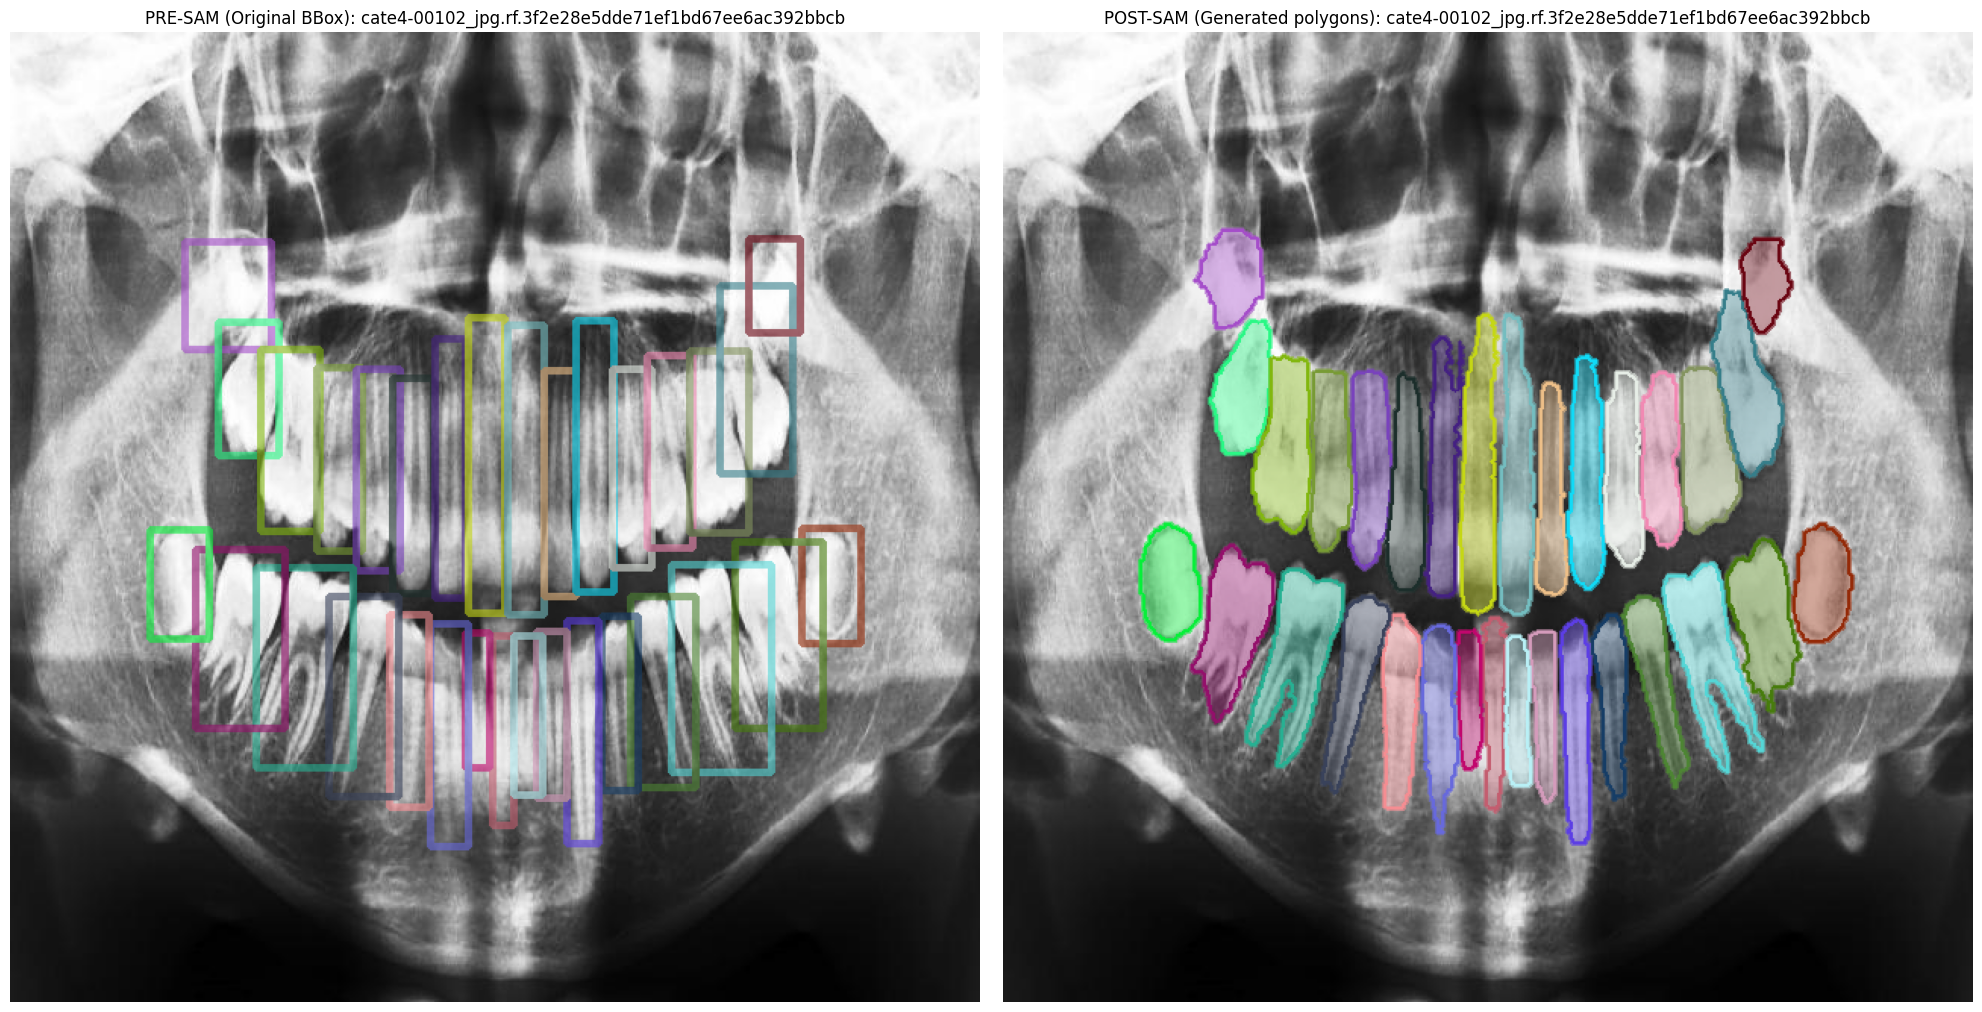

In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import glob

## PATH CONFIG
IMG_DIR = "/kaggle/working/data/SAM/UFBA/test/images"
PRE_SAM_LBL_DIR = "/kaggle/working/data/SAM/UFBA/test/labels"
POST_SAM_LBL_DIR = "/kaggle/working/out-ufba"

# loading processed files
label_files = glob.glob(os.path.join(POST_SAM_LBL_DIR, "*.txt"))

if not label_files:
    print(f"ERROR: No file found in {POST_SAM_LBL_DIR}.")
else:
    # Random file choice
    random_label_path = random.choice(label_files)
    base_name = os.path.basename(random_label_path)
    img_base = os.path.splitext(base_name)[0]
    
    img_path = os.path.join(IMG_DIR, img_base + ".jpg")
    pre_label_path = os.path.join(PRE_SAM_LBL_DIR, base_name)
    post_label_path = random_label_path

    if not os.path.exists(img_path):
        print(f"ERROR: Image not found in {img_path}")
    else:
        def draw_annotations(label_path, is_polygon=True):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            overlay = img.copy()
            
            if not os.path.exists(label_path):
                return img

            with open(label_path, 'r') as f:
                lines = f.readlines()
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5: continue
                
                class_id = int(float(parts[0]))
                random.seed(class_id)
                color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
                
                if not is_polygon or len(parts) == 5:
                    # Draw BOX (YOLO format: class x_c y_c w h)
                    x_c, y_c, bw, bh = map(float, parts[1:])
                    x1 = int((x_c - bw/2) * w)
                    y1 = int((y_c - bh/2) * h)
                    x2 = int((x_c + bw/2) * w)
                    y2 = int((y_c + bh/2) * h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
                else:
                    # Draw Polygon
                    coords = map(float, parts[1:])
                    points = []
                    it = iter(coords)
                    for px, py in zip(it, it):
                        points.append([int(px * w), int(py * h)])
                    
                    pts = np.array(points, np.int32).reshape((-1, 1, 2))
                    cv2.fillPoly(overlay, [pts], color)
                    cv2.polylines(img, [pts], True, color, 2)

            alpha = 0.4
            return cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
        
        # PLOTS
        img_pre = draw_annotations(pre_label_path, is_polygon=False)
        img_post = draw_annotations(post_label_path, is_polygon=True)

        fig, axes = plt.subplots(1, 2, figsize=(20, 10))
        
        axes[0].imshow(img_pre)
        axes[0].set_title(f"PRE-SAM (Original BBox): {img_base}")
        axes[0].axis('off')
        
        axes[1].imshow(img_post)
        axes[1].set_title(f"POST-SAM (Generated polygons): {img_base}")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()